In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
n = 100000


In [3]:
data = pd.DataFrame({
    'Customer_ID': range(1, n+1),
    'Age': np.random.randint(18, 70, n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Tenure': np.random.randint(0, 11, n),
    'Balance': np.random.randint(0, 200000, n),
    'CreditScore': np.random.randint(300, 901, n),
    'EstimatedSalary': np.random.randint(10000, 150001, n),
    'NumOfProducts': np.random.randint(1, 5, n),
    'IsActiveMember': np.random.choice(['Yes', 'No'], n)
})

In [5]:
data['Chrun'] = (
    (data['IsActiveMember'] == 'No').astype(int) +
    (data['NumOfProducts'] == 1).astype(int) +
    (data['Tenure'] < 3).astype(int)
)

data['Chrun'] = data['Chrun'].apply(lambda x: 1 if x >= 2 else 0)

print("\nSample Data:")
print(data.head())


Sample Data:
   Customer_ID  Age  Gender  Tenure  Balance  CreditScore  EstimatedSalary  \
0            1   56  Female       6   117444          424           128126   
1            2   69  Female       5    19619          405            94708   
2            3   46    Male       6   193753          881            49658   
3            4   32    Male       9   182570          823            61391   
4            5   60    Male       2    19321          570            21378   

   NumOfProducts IsActiveMember  Churn  Chrun  
0              1             No      1      1  
1              1            Yes      0      0  
2              4            Yes      0      0  
3              3            Yes      0      0  
4              4            Yes      0      0  


In [6]:
print("\nMissing Values:")
print(data.isnull().sum())
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
data['IsActiveMember'] = data['IsActiveMember'].map({'No': 0, 'Yes': 1})


Missing Values:
Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
Chrun              0
dtype: int64


In [7]:
print("\nDescriptive Statistics:")
print(data.describe())

print("\nMean:\n", data.mean())
print("\nMedian:\n", data.median())
print("\nMode:\n", data.mode().iloc[0])
print("\nStandard Deviation:\n", data.std())


Descriptive Statistics:
         Customer_ID            Age         Gender         Tenure  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean    50000.500000      43.500270       0.498800       4.990560   
std     28867.657797      14.970933       0.500001       3.163813   
min         1.000000      18.000000       0.000000       0.000000   
25%     25000.750000      31.000000       0.000000       2.000000   
50%     50000.500000      43.000000       0.000000       5.000000   
75%     75000.250000      56.000000       1.000000       8.000000   
max    100000.000000      69.000000       1.000000      10.000000   

             Balance    CreditScore  EstimatedSalary  NumOfProducts  \
count  100000.000000  100000.000000    100000.000000  100000.000000   
mean    99716.211330     599.957920     79974.436290       2.501380   
std     57671.454404     173.286152     40436.829792       1.117565   
min         0.000000     300.000000     10000.000000       1.000000  

In [10]:
print("\nChrun Count:")
print(data['Churn'].value_counts())



Chrun Count:
Churn
0    73857
1    26143
Name: count, dtype: int64


In [11]:
print("\nChrun by Gender:")
print(data.groupby('Gender')['Chrun'].mean())

print("\nChrun by Activity:")
print(data.groupby('IsActiveMember')['Chrun'].mean())

print("\nChurn by Products:")
print(data.groupby('NumOfProducts')['Chrun'].mean())


Chrun by Gender:
Gender
0    0.261413
1    0.261447
Name: Chrun, dtype: float64

Chrun by Activity:
IsActiveMember
0    0.452778
1    0.069284
Name: Chrun, dtype: float64

Churn by Products:
NumOfProducts
1    0.633442
2    0.138804
3    0.137068
4    0.137382
Name: Chrun, dtype: float64


In [12]:
print("\nCorrelation Matrix:")
print(data.corr())


Correlation Matrix:
                 Customer_ID       Age    Gender    Tenure   Balance  \
Customer_ID         1.000000  0.000520  0.003559  0.005354 -0.001137   
Age                 0.000520  1.000000 -0.002125 -0.000659  0.001446   
Gender              0.003559 -0.002125  1.000000  0.005297 -0.001962   
Tenure              0.005354 -0.000659  0.005297  1.000000  0.004931   
Balance            -0.001137  0.001446 -0.001962  0.004931  1.000000   
CreditScore        -0.006147 -0.002394 -0.002172 -0.001817  0.005021   
EstimatedSalary    -0.003079  0.000014 -0.003224 -0.004857 -0.007925   
NumOfProducts      -0.001204 -0.008485 -0.000498 -0.001693 -0.000625   
IsActiveMember     -0.004434 -0.005986 -0.003085 -0.005026  0.001553   
Churn              -0.002574  0.002328  0.000040 -0.391006 -0.003507   
Chrun              -0.002574  0.002328  0.000040 -0.391006 -0.003507   

                 CreditScore  EstimatedSalary  NumOfProducts  IsActiveMember  \
Customer_ID        -0.006147      

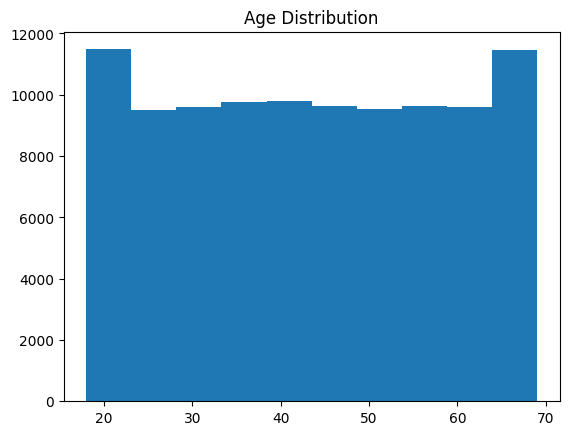

In [13]:
plt.hist(data['Age'])
plt.title("Age Distribution")
plt.show()

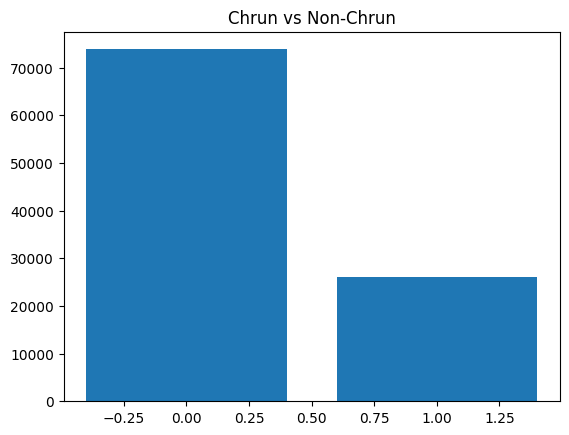

In [14]:
chrun_counts = data['Chrun'].value_counts()
plt.bar(chrun_counts.index, chrun_counts.values)
plt.title("Chrun vs Non-Chrun")
plt.show()



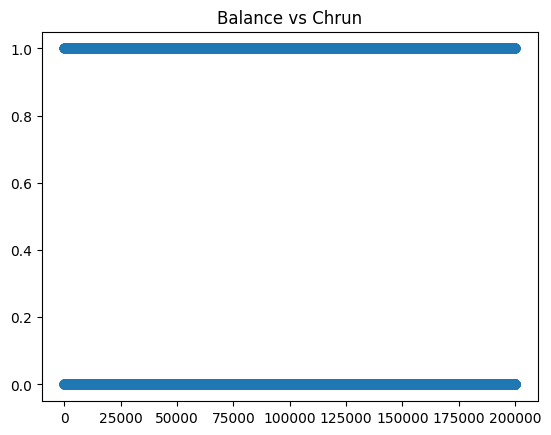

In [15]:
plt.scatter(data['Balance'], data['Chrun'])
plt.title("Balance vs Chrun")
plt.show()



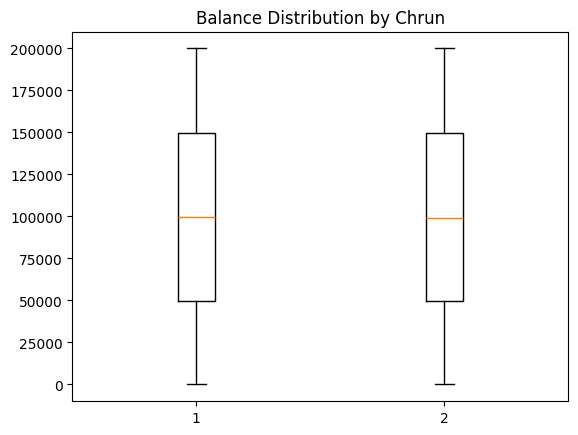

In [16]:
plt.boxplot([data[data['Chrun']==0]['Balance'], data[data['Chrun']==1]['Balance']])
plt.title("Balance Distribution by Chrun")
plt.show()


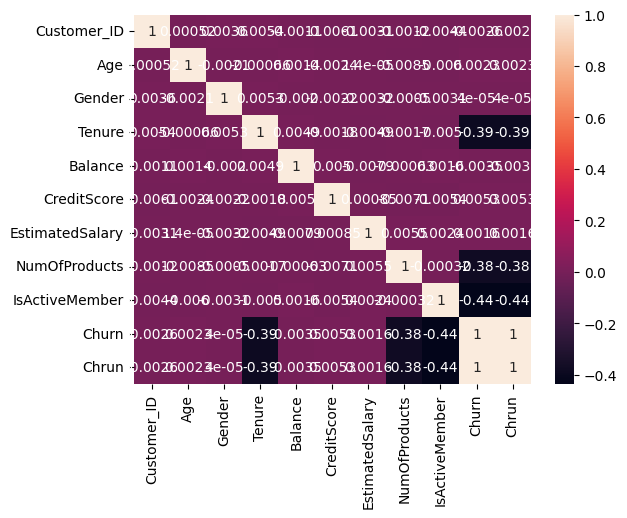

In [17]:
import seaborn as sns
sns.heatmap(data.corr(), annot=True)
plt.show()



In [18]:
print("\nKey Insights:")
print("- Inactive users are more likely to chrun")
print("- Customers with fewer products chrun more")
print("- Low tenure customers show higher chrun")


Key Insights:
- Inactive users are more likely to chrun
- Customers with fewer products chrun more
- Low tenure customers show higher chrun
